## imports and setup

In [1]:
%env DJ_SUPPORT_FILEPATH_MANAGEMENT TRUE
%load_ext autoreload
%autoreload 2
%matplotlib inline

env: DJ_SUPPORT_FILEPATH_MANAGEMENT=TRUE


In [2]:
import hydra
from omegaconf import DictConfig, OmegaConf
import os
from time import sleep
import pickle


## configs

In [7]:
cwd = os.getcwd()
path_to_repo = "GitRepos/simulation_closed_loop"
full_repo_path = os.path.join(cwd,path_to_repo)

config_path = os.path.join(full_repo_path, "config")
assert os.path.exists(config_path), f"Config path {config_path} does not exist."

# Initialize Hydra
try:
    hydra.initialize(config_path=config_path,)
except Exception as e:
    print(f"Likely alredy initialized hydra, need ot restart kernel to reinitialize. Error: {e}")

# Compose the configuration
cfg = hydra.compose(config_name="config")

import sys
sys.path.append(full_repo_path)

Likely alredy initialized hydra, need ot restart kernel to reinitialize. Error: config_path in initialize() must be relative


/tmp/ipykernel_1941336/2780081250.py:10: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize(config_path=config_path,)


MissingConfigException: In 'openretina/hoefling_2024_core_readout_low_res': Could not find 'openretina/dataloader/hoefling_2024'

Config search path:
	provider=hydra, path=pkg://hydra.conf
	provider=main, path=file:///gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/config
	provider=schema, path=structured://

In [3]:
import hydra
from omegaconf import OmegaConf
import os


# Simple path setup
config_dir = "GitRepos/simulation_closed_loop/config"

# Initialize Hydra simply
hydra.initialize(config_path=config_dir, version_base="1.3")
cfg = hydra.compose(config_name="config")

# Add repo to path
import sys
sys.path.append("GitRepos/simulation_closed_loop")

MissingConfigException: In 'openretina/hoefling_2024_core_readout_low_res': Could not find 'openretina/dataloader/hoefling_2024'

Config search path:
	provider=hydra, path=pkg://hydra.conf
	provider=main, path=file:///gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/config
	provider=schema, path=structured://

## get simulation loop components

In [4]:
from simulations.run_simulation import create_loop_components
recorder, preprocessor, model, stimulator = create_loop_components(cfg)


Removed closedloopmousecamera1.h5 from /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/stimuli/updated_loop_data
Removed closedloopmousecamera0.h5 from /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/stimuli/updated_loop_data


/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/simulations/loop_components/preprocessors/preprocessor1.py:108: UserWarning: There are files already in /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/model_input. They will be overwritten
  warnings.warn(f"There are files already in {self.openretina_processed_data_path}. They will be overwritten", category=UserWarning)


In [3]:
from simulations.loop_components.dj_wrappers import OpenRetinaWrapper
# create preprocessor
openretinawrapper = OpenRetinaWrapper(
                username=cfg.DJ.username, # type: ignore
                home_directory=cfg.paths.home_directory, # type: ignore
                repo_directory=cfg.paths.repo_directory, # type: ignore
                dj_config_directory= cfg.paths.dj_config_directory, # type: ignore
                rgc_output_directory= cfg.paths.rgc_output_directory, # type: ignore
                userinfo= cfg.DJ.userinfo, # type: ignore
                # from overall configs 
                debug=cfg.debug, # type: ignore
                )

ModuleNotFoundError: No module named 'simulations'

In [5]:
openretinawrapper.setup()

[2025-05-29 14:34:23,081][INFO]: Connecting ssuhai@172.25.240.200:3306
[2025-05-29 14:34:23,139][INFO]: Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_closed_loop


TypeError: 'NoneType' object is not subscriptable

## Run the simulation

Iteration 1/1
Copied noise file from /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/stimuli/static_test_data/closedloopmousecamera.h5 to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/stimuli/updated_loop_data/closedloopmousecamera0.h5


[2025-05-07 17:00:49,928][INFO]: Connecting ssuhai@172.25.240.200:3306
[2025-05-07 17:00:49,993][INFO]: Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_test


[2025-05-07 17:00:59,355][INFO]: Deleting 6 rows from `ageuler_ssuhai_test`.`__field__stack_averages`
[2025-05-07 17:00:59,379][INFO]: Deleting 2 rows from `ageuler_ssuhai_test`.`__field`
[2025-05-07 17:00:59,404][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`#raw_data_params`
[2025-05-07 17:00:59,470][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`__experiment__animal`
[2025-05-07 17:00:59,519][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`__experiment__exp_info`
[2025-05-07 17:00:59,566][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`__experiment__indicator`
[2025-05-07 17:00:59,612][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`__experiment__pharm_info`
[2025-05-07 17:00:59,636][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`__experiment`
[2025-05-07 17:00:59,662][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`user_info`
[2025-05-07 17:01:04,590][INFO]: Deletes committed.
[2025-05-07 17:01:05,619][INFO]: Deleting 0 rows from `ageuler_ssuhai_test`.`__ex

Scanning for experimenter: closedlooptest
	header_path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20250412/1
		header_name: 20220217__left.ini
		Adding: {'experimenter': 'closedlooptest', 'date': datetime.datetime(2025, 4, 12, 0, 0), 'exp_num': 1}
Found 1 files in 1 fields for key={'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1}
	Adding field: `{'field': 'GCL0', 'region': 'LR', 'cond1': 'iter0', 'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1}`
stimulus trace not implemented yet !!!!!!!!!!!


Presentation: 100%|██████████| 1/1 [03:26<00:00, 206.47s/it]



field_key: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL0', 'region': 'LR', 'cond1': 'iter0'} 
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL0', 'region': 'LR', 'cond1': 'iter0', 'stim_name': 'closedloopmousecamera0', 'cond2': 'control'}]
No ROI masks found for field: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL0', 'region': 'LR', 'cond1': 'iter0'}
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL0', 'region': 'LR', 'cond1': 'iter0', 'stim_name': 'closedloopmousecamera0', 'cond2': 'control'}]
Load model weights for cpu from checkpoint /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/dropout_and_aug_regul.ckpt using config /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/sd_images.yaml


Returned InteractiveRoiCanvas object. To start GUI, call <enter_object_name>.start_gui().


Processes: 100%|██████████| 101/101 [00:00<00:00, 114.48it/s]


TypeError: 'NoneType' object is not subscriptable

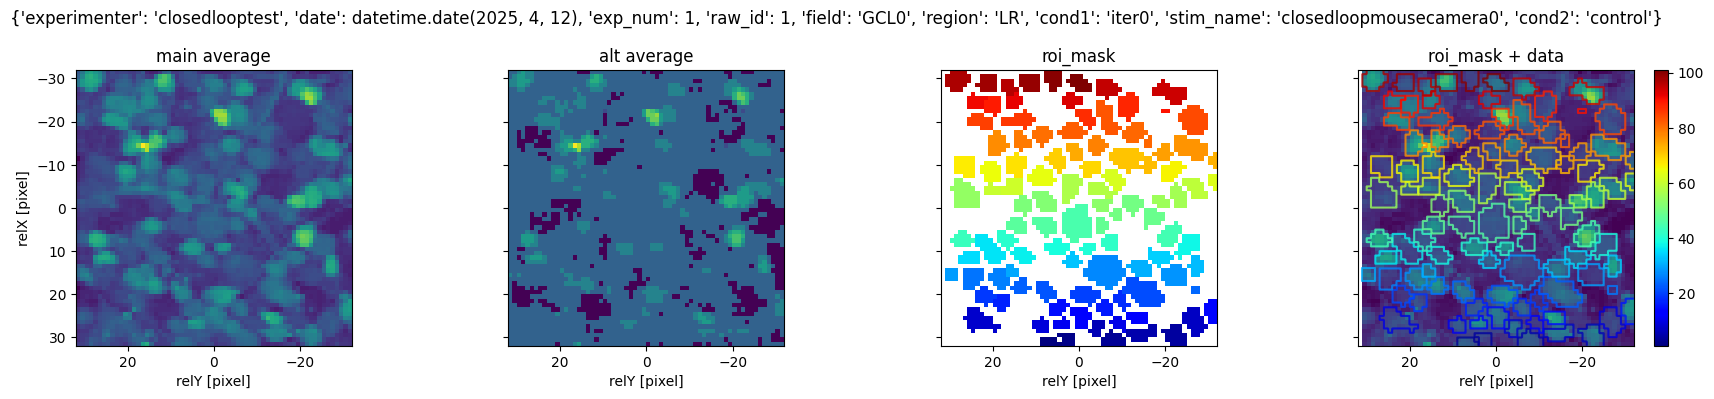

In [5]:
iterations = 1 
all_traces = []
for iter in range(iterations):
    print(f"Iteration {iter+1}/{iterations}")
   
    # show stimulus 
    stimulator.stimulate()

    # Run the simulation
    recorder.record()
    
    # Process the data
    preprocessor.process_data(connect_and_activate=True)
    
    # sleep 
    sleep(1)
    





In [6]:
stimulator.clean_up()
recorder.clean_up()
preprocessor.clean_up()


Removed closedloopmousecamera0.h5 from /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/stimuli/updated_loop_data


[2025-05-07 17:08:27,829][INFO]: Deleting 3 rows from `ageuler_ssuhai_test`.`__field__stack_averages`
[2025-05-07 17:08:27,902][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`__presentation__scan_info`
[2025-05-07 17:08:27,949][INFO]: Deleting 3 rows from `ageuler_ssuhai_test`.`__presentation__stack_averages`
[2025-05-07 17:08:28,028][INFO]: Deleting 101 rows from `ageuler_ssuhai_test`.`__preprocess_traces`
[2025-05-07 17:08:28,064][INFO]: Deleting 101 rows from `ageuler_ssuhai_test`.`__traces`
[2025-05-07 17:08:28,104][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`roi_mask__roi_mask_presentation`
[2025-05-07 17:08:28,179][INFO]: Deleting 101 rows from `ageuler_ssuhai_test`.`__roi`
[2025-05-07 17:08:28,205][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`roi_mask`
[2025-05-07 17:08:28,230][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`__presentation`
[2025-05-07 17:08:28,254][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`__field`
[2025-05-07 17:08:28,279][INFO]: D